In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/mexwell/nuclear-weapons/nuclear-weapons-proliferation.csv
/kaggle/input/datasets/mexwell/nuclear-weapons/nuclear-warhead-stockpiles-lines.csv
/kaggle/input/datasets/mexwell/nuclear-weapons/estimated-megatons-of-nuclear-weapons-deliverable-in-first-strike.csv
/kaggle/input/datasets/mexwell/nuclear-weapons/number-of-nuclear-weapons-tests.csv
/kaggle/input/datasets/mexwell/nuclear-weapons/nuclear-warhead-inventories.csv


In [2]:
import pandas as pd
data=pd.read_csv('/kaggle/input/datasets/mexwell/nuclear-weapons/nuclear-warhead-inventories.csv')
data.head()

,Entity,Code,Year,Number of deployed strategic nuclear warheads,Number of deployed nonstrategic nuclear warheads,Number of nondeployed nuclear warheads in reserve,Number of retired nuclear warheads
0,China,CHN,2023,0,0,410,0
1,France,FRA,2023,280,0,10,0
2,India,IND,2023,0,0,164,0
3,Israel,ISR,2023,0,0,90,0
4,North Korea,PRK,2023,0,0,30,0


In [3]:
#Data Cleaning Code

import pandas as pd

# Load dataset
data = pd.read_csv('/kaggle/input/datasets/mexwell/nuclear-weapons/nuclear-warhead-inventories.csv')

# Clean column names
data.columns = data.columns.str.strip().str.lower().str.replace(' ', '_')

# Detect columns
for col in data.columns:
    if 'entity' in col:
        country_col = col
    elif 'year' in col:
        year_col = col
    elif 'warhead' in col:
        warhead_col = col

# Convert data types
data[year_col] = pd.to_numeric(data[year_col], errors='coerce')
data[warhead_col] = pd.to_numeric(data[warhead_col], errors='coerce')

# Remove missing values
data = data.dropna(subset=[year_col])

# Fill missing warheads
data[warhead_col] = data[warhead_col].fillna(0)

# Remove invalid values
data = data[data[warhead_col] >= 0]

# Convert year to integer
data[year_col] = data[year_col].astype(int)

# Remove duplicates
data = data.drop_duplicates()

# Final check
print(data.info())
print(data.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 7 columns):
 #   Column                                             Non-Null Count  Dtype 
---  ------                                             --------------  ----- 
 0   entity                                             9 non-null      object
 1   code                                               9 non-null      object
 2   year                                               9 non-null      int64 
 3   number_of_deployed_strategic_nuclear_warheads      9 non-null      int64 
 4   number_of_deployed_nonstrategic_nuclear_warheads   9 non-null      int64 
 5   number_of_nondeployed_nuclear_warheads_in_reserve  9 non-null      int64 
 6   number_of_retired_nuclear_warheads                 9 non-null      int64 
dtypes: int64(5), object(2)
memory usage: 636.0+ bytes
None
        entity code  year  number_of_deployed_strategic_nuclear_warheads  \
0        China  CHN  2023                            

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets

# -------------------------------
# 1. Load Dataset
# -------------------------------
data = pd.read_csv('/kaggle/input/datasets/mexwell/nuclear-weapons/nuclear-warhead-inventories.csv')

# -------------------------------
# 2. Clean Columns
# -------------------------------
data.columns = data.columns.str.strip().str.lower().str.replace(' ', '_')

# Detect columns automatically
for col in data.columns:
    if 'entity' in col:
        country_col = col
    elif 'year' in col:
        year_col = col
    elif 'warhead' in col:
        warhead_col = col

# Convert types
data[year_col] = pd.to_numeric(data[year_col], errors='coerce')
data[warhead_col] = pd.to_numeric(data[warhead_col], errors='coerce')

data = data.dropna(subset=[year_col])
data[warhead_col] = data[warhead_col].fillna(0)
data = data[data[warhead_col] >= 0]
data[year_col] = data[year_col].astype(int)

# -------------------------------
# 3. Widgets (USER INPUT)
# -------------------------------
countries = sorted(data[country_col].unique())

country_select = widgets.SelectMultiple(
    options=countries,
    description='Countries',
)

year_slider = widgets.IntSlider(
    min=int(data[year_col].min()),
    max=int(data[year_col].max()),
    value=int(data[year_col].max()),
    description='Year'
)

top_n_slider = widgets.IntSlider(
    min=3,
    max=15,
    value=10,
    description='Top N'
)

# -------------------------------
# 4. Bar Graph Function
# -------------------------------
def plot_bar(countries, year, top_n):
    
    # Filter by year
    filtered = data[data[year_col] == year]
    
    if len(countries) > 0:
        filtered = filtered[filtered[country_col].isin(countries)]
    else:
        # If no country selected → show top N
        filtered = filtered.sort_values(by=warhead_col, ascending=False).head(top_n)
    
    if filtered.empty:
        print("No data available.")
        return
    
    # Sort for better visualization
    filtered = filtered.sort_values(by=warhead_col, ascending=False)
    
    # Plot
    plt.figure()
    plt.bar(filtered[country_col], filtered[warhead_col])
    plt.xticks(rotation=45)
    plt.title(f"Nuclear Warheads by Country ({year})")
    plt.xlabel("Country")
    plt.ylabel("Warheads")
    plt.grid()
    plt.show()

# -------------------------------
# 5. Interactive UI
# -------------------------------
widgets.interact(
    plot_bar,
    countries=country_select,
    year=year_slider,
    top_n=top_n_slider
)

interactive(children=(SelectMultiple(description='Countries', options=('China', 'France', 'India', 'Israel', '…

<function __main__.plot_bar(countries, year, top_n)>

In [5]:
#  Data Processing Code

import pandas as pd

# -------------------------------
# 1. Load + Basic Cleaning
# -------------------------------
data = pd.read_csv('/kaggle/input/datasets/mexwell/nuclear-weapons/nuclear-warhead-inventories.csv')

data.columns = data.columns.str.strip().str.lower().str.replace(' ', '_')

# Detect columns
for col in data.columns:
    if 'entity' in col:
        country_col = col
    elif 'year' in col:
        year_col = col
    elif 'warhead' in col:
        warhead_col = col

# Convert types
data[year_col] = pd.to_numeric(data[year_col], errors='coerce')
data[warhead_col] = pd.to_numeric(data[warhead_col], errors='coerce')

data = data.dropna(subset=[year_col])
data[warhead_col] = data[warhead_col].fillna(0)
data = data[data[warhead_col] >= 0]
data[year_col] = data[year_col].astype(int)

# -------------------------------
# 2. DATA PROCESSING STARTS HERE
# -------------------------------

# Sort data (important for time analysis)
data = data.sort_values(by=[country_col, year_col])

# -------------------------------
# 3. Aggregation (Total warheads per year)
# -------------------------------
yearly_total = data.groupby(year_col)[warhead_col].sum().reset_index()

# -------------------------------
# 4. Aggregation (Latest year per country)
# -------------------------------
latest_year = data[year_col].max()
latest_data = data[data[year_col] == latest_year]

# -------------------------------
# 5. Top Countries (processed result)
# -------------------------------
top_countries = latest_data.sort_values(by=warhead_col, ascending=False).head(10)

# -------------------------------
# 6. Feature Engineering
# -------------------------------

# Yearly change in warheads per country
data['yearly_change'] = data.groupby(country_col)[warhead_col].diff()

# Growth rate (% change)
data['growth_rate'] = data.groupby(country_col)[warhead_col].pct_change() * 100

# -------------------------------
# 7. Summary Statistics
# -------------------------------
summary = data.groupby(country_col)[warhead_col].agg(['mean', 'max', 'min'])

# -------------------------------
# 8. Output Processed Data
# -------------------------------
print("Yearly Total:\n", yearly_total.head())
print("\nTop Countries:\n", top_countries)
print("\nSummary Stats:\n", summary.head())


Yearly Total:
    year  number_of_retired_nuclear_warheads
0  2023                                2936

Top Countries:
            entity code  year  number_of_deployed_strategic_nuclear_warheads  \
8   United States  USA  2023                                           1670   
6          Russia  RUS  2023                                           1674   
0           China  CHN  2023                                              0   
1          France  FRA  2023                                            280   
2           India  IND  2023                                              0   
4     North Korea  PRK  2023                                              0   
3          Israel  ISR  2023                                              0   
5        Pakistan  PAK  2023                                              0   
7  United Kingdom  GBR  2023                                            120   

   number_of_deployed_nonstrategic_nuclear_warheads  \
8                                 

In [6]:
#Data Insights

import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets

# -------------------------------
# 1. LOAD DATA
# -------------------------------
data = pd.read_csv('/kaggle/input/datasets/mexwell/nuclear-weapons/nuclear-warhead-inventories.csv')

# -------------------------------
# 2. DATA CLEANING
# -------------------------------
data.columns = data.columns.str.strip().str.lower().str.replace(' ', '_')

# Detect columns
country_col, year_col, warhead_col = None, None, None
for col in data.columns:
    if 'entity' in col:
        country_col = col
    elif 'year' in col:
        year_col = col
    elif 'warhead' in col:
        warhead_col = col

# Convert types
data[year_col] = pd.to_numeric(data[year_col], errors='coerce')
data[warhead_col] = pd.to_numeric(data[warhead_col], errors='coerce')

# Handle missing values
data = data.dropna(subset=[year_col])
data[warhead_col] = data[warhead_col].fillna(0)

# Remove invalid values
data = data[data[warhead_col] >= 0]

# Convert year
data[year_col] = data[year_col].astype(int)

# Remove duplicates
data = data.drop_duplicates()

print("Data Cleaning Completed\n")

# -------------------------------
# 3. DATA PROCESSING
# -------------------------------
data = data.sort_values(by=[country_col, year_col])

# Yearly total
yearly_total = data.groupby(year_col)[warhead_col].sum()

# Latest year data
latest_year = data[year_col].max()
latest = data[data[year_col] == latest_year]

# -------------------------------
# 4. DATA INSIGHTS
# -------------------------------
print("===== DATA INSIGHTS =====\n")

# Highest country
top_country = latest.loc[latest[warhead_col].idxmax()]
print(f"1. Highest warheads in {latest_year}:")
print(f"   {top_country[country_col]} → {int(top_country[warhead_col])}\n")

# Top 5 countries
print("2. Top 5 countries:")
top5 = latest.sort_values(by=warhead_col, ascending=False).head(5)
for _, row in top5.iterrows():
    print(f"   {row[country_col]} → {int(row[warhead_col])}")
print()

# Peak global year
max_year = yearly_total.idxmax()
print(f"3. Peak global warheads: {max_year} → {int(yearly_total.max())}\n")

# Growth analysis (FIXED VERSION)
data['change'] = data.groupby(country_col)[warhead_col].diff()

valid_change = data.dropna(subset=['change'])

if not valid_change.empty:
    max_growth = valid_change.loc[valid_change['change'].idxmax()]
    print("4. Largest increase:")
    print(f"   {max_growth[country_col]} ({int(max_growth[year_col])}) → +{int(max_growth['change'])}\n")

    min_growth = valid_change.loc[valid_change['change'].idxmin()]
    print("5. Largest decrease:")
    print(f"   {min_growth[country_col]} ({int(min_growth[year_col])}) → {int(min_growth['change'])}\n")
else:
    print("No growth data available.\n")

# -------------------------------
# 5. INTERACTIVE BAR GRAPH
# -------------------------------
countries = sorted(data[country_col].unique())

country_select = widgets.SelectMultiple(
    options=countries,
    description='Countries'
)

year_slider = widgets.IntSlider(
    min=int(data[year_col].min()),
    max=int(data[year_col].max()),
    value=latest_year,
    description='Year'
)

top_n_slider = widgets.IntSlider(
    min=3,
    max=15,
    value=10,
    description='Top N'
)

def plot_bar(countries, year, top_n):
    
    filtered = data[data[year_col] == year]
    
    if len(countries) > 0:
        filtered = filtered[filtered[country_col].isin(countries)]
    else:
        filtered = filtered.sort_values(by=warhead_col, ascending=False).head(top_n)
    
    if filtered.empty:
        print("No data available.")
        return
    
    filtered = filtered.sort_values(by=warhead_col, ascending=False)
    
    plt.figure()
    plt.bar(filtered[country_col], filtered[warhead_col])
    plt.xticks(rotation=45)
    plt.title(f"Nuclear Warheads by Country ({year})")
    plt.xlabel("Country")
    plt.ylabel("Warheads")
    plt.grid()
    plt.show()

widgets.interact(
    plot_bar,
    countries=country_select,
    year=year_slider,
    top_n=top_n_slider
)

Data Cleaning Completed

===== DATA INSIGHTS =====

1. Highest warheads in 2023:
   United States → 1536

2. Top 5 countries:
   United States → 1536
   Russia → 1400
   China → 0
   France → 0
   India → 0

3. Peak global warheads: 2023 → 2936

No growth data available.



interactive(children=(SelectMultiple(description='Countries', options=('China', 'France', 'India', 'Israel', '…

<function __main__.plot_bar(countries, year, top_n)>

Available Columns: ['entity', 'code', 'year', 'number_of_deployed_strategic_nuclear_warheads', 'number_of_deployed_nonstrategic_nuclear_warheads', 'number_of_nondeployed_nuclear_warheads_in_reserve', 'number_of_retired_nuclear_warheads']

Detected Columns:
Country: entity
Year: year
Warheads: number_of_retired_nuclear_warheads


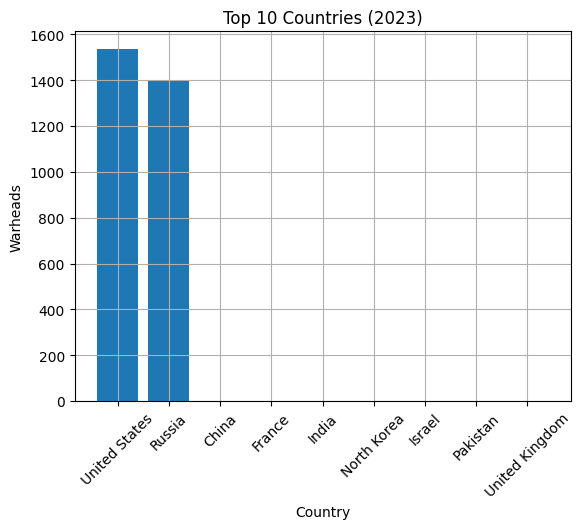

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------
# 1. Load Dataset
# -------------------------------
data = pd.read_csv('/kaggle/input/datasets/mexwell/nuclear-weapons/nuclear-warhead-inventories.csv')

# -------------------------------
# 2. Clean Column Names
# -------------------------------
data.columns = data.columns.str.strip().str.lower().str.replace(' ', '_')

print("Available Columns:", list(data.columns))

# -------------------------------
# 3. AUTO-DETECT COLUMNS
# -------------------------------
country_col, year_col, warhead_col = None, None, None

for col in data.columns:
    if 'entity' in col or 'country' in col:
        country_col = col
    elif 'year' in col:
        year_col = col
    elif 'warhead' in col or 'nuclear' in col:
        warhead_col = col

# Check if detection worked
if not all([country_col, year_col, warhead_col]):
    raise Exception("Column detection failed. Check dataset manually.")

print("\nDetected Columns:")
print("Country:", country_col)
print("Year:", year_col)
print("Warheads:", warhead_col)

# -------------------------------
# 4. Convert Data Types
# -------------------------------
data[year_col] = pd.to_numeric(data[year_col], errors='coerce')
data[warhead_col] = pd.to_numeric(data[warhead_col], errors='coerce')

# Remove invalid data
data = data.dropna(subset=[year_col])
data[warhead_col] = data[warhead_col].fillna(0)
data = data[data[warhead_col] >= 0]

data[year_col] = data[year_col].astype(int)

# -------------------------------
# 5. Visualization (BAR GRAPH)
# -------------------------------
latest_year = data[year_col].max()
latest = data[data[year_col] == latest_year]

# Check before sorting (prevents KeyError)
if warhead_col not in latest.columns:
    raise Exception(f"{warhead_col} not found in dataset!")

top = latest.sort_values(by=warhead_col, ascending=False).head(10)

# Plot
plt.figure()
plt.bar(top[country_col], top[warhead_col])
plt.xticks(rotation=45)
plt.title(f"Top 10 Countries ({latest_year})")
plt.xlabel("Country")
plt.ylabel("Warheads")
plt.grid()
plt.show()

In [8]:
import pandas as pd

# -------------------------------
# 1. Load Dataset
# -------------------------------
data = pd.read_csv('/kaggle/input/datasets/mexwell/nuclear-weapons/nuclear-warhead-inventories.csv')

# -------------------------------
# 2. Data Cleaning
# -------------------------------
data.columns = data.columns.str.strip().str.lower().str.replace(' ', '_')

# Detect columns automatically
country_col, year_col, warhead_col = None, None, None

for col in data.columns:
    if 'entity' in col or 'country' in col:
        country_col = col
    elif 'year' in col:
        year_col = col
    elif 'warhead' in col or 'nuclear' in col:
        warhead_col = col

# Convert types
data[year_col] = pd.to_numeric(data[year_col], errors='coerce')
data[warhead_col] = pd.to_numeric(data[warhead_col], errors='coerce')

data = data.dropna(subset=[year_col])
data[warhead_col] = data[warhead_col].fillna(0)
data = data[data[warhead_col] >= 0]
data[year_col] = data[year_col].astype(int)

# -------------------------------
# 3. Data Processing
# -------------------------------
data = data.sort_values(by=[country_col, year_col])

latest_year = data[year_col].max()
latest = data[data[year_col] == latest_year]

yearly_total = data.groupby(year_col)[warhead_col].sum()

# -------------------------------
# 4. Insights
# -------------------------------
report = []

report.append("EXPLORATORY DATA ANALYSIS REPORT")
report.append("Nuclear Warhead Inventory Analysis\n")

# Dataset info
report.append(f"Dataset contains {data.shape[0]} rows and {data.shape[1]} columns.\n")

# Top country
top_country = latest.loc[latest[warhead_col].idxmax()]
report.append(f"Highest warheads in {latest_year}: {top_country[country_col]} ({int(top_country[warhead_col])})")

# Top 5 countries
top5 = latest.sort_values(by=warhead_col, ascending=False).head(5)
report.append("\nTop 5 Countries:")
for _, row in top5.iterrows():
    report.append(f"{row[country_col]} → {int(row[warhead_col])}")

# Peak year
peak_year = yearly_total.idxmax()
report.append(f"\nPeak global warheads: {peak_year} ({int(yearly_total.max())})")

# Growth analysis (safe)
data['change'] = data.groupby(country_col)[warhead_col].diff()
valid_change = data.dropna(subset=['change'])

if not valid_change.empty:
    max_growth = valid_change.loc[valid_change['change'].idxmax()]
    report.append(f"\nLargest increase: {max_growth[country_col]} ({int(max_growth[year_col])}) +{int(max_growth['change'])}")

    min_growth = valid_change.loc[valid_change['change'].idxmin()]
    report.append(f"Largest decrease: {min_growth[country_col]} ({int(min_growth[year_col])}) {int(min_growth['change'])}")

# Conclusion
report.append("\nCONCLUSION:")
report.append("The dataset shows clear trends in nuclear warhead distribution, with a few countries dominating global stockpiles.")
report.append("Over time, fluctuations indicate periods of buildup and reduction, reflecting geopolitical changes.")

# -------------------------------
# 5. Save Report
# -------------------------------
with open("EDA_Report.txt", "w") as f:
    for line in report:
        f.write(line + "\n")

print("Report generated successfully: EDA_Report.txt")

Report generated successfully: EDA_Report.txt
